# **Monocular Depth Estimation vs. Classical Stereo**

## **Objectives:**
1. Estimate a full depth map from a **single** photo with Depth Anything V2 Small, via `onnxruntime` — no second camera, no calibration, no correspondence matching at all
2. Grade it against the exact same real, independently-measured ground truth (`aloeGT.png`) notebook 32 used for `StereoBM`/`StereoSGBM`
3. Find out how close a model that never sees stereo geometry gets to a method built entirely around it

> **Assets.** `assets/models/depth_anything_v2_small.onnx` is [depth-anything/Depth-Anything-V2-Small](https://huggingface.co/depth-anything/Depth-Anything-V2-Small) (Apache 2.0 — unlike the Base/Large checkpoints in the same family, which are CC-BY-NC-4.0 and non-commercial), exported to ONNX by [onnx-community](https://huggingface.co/onnx-community/depth-anything-v2-small) (also Apache 2.0), `model_quantized.onnx` (~27MB, int8). Reuses notebook 32's `aloeL.jpg` / `aloeGT.png` ([opencv/opencv](https://github.com/opencv/opencv/tree/4.x/samples/data), Apache 2.0) so both methods are graded against the exact same measured ground truth.
>
> Loaded with `onnxruntime` directly, same reason as notebook 37's MobileSAM — dynamic input resolution (any size, as long as both dimensions are multiples of 14) isn't the fixed-shape single-graph shape `cv2.dnn`'s ONNX importer expects.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Two completely different routes to the same answer**

Notebook 32's stereo pipeline recovers depth from *geometry*: two cameras, a known baseline, and explicit per-pixel correspondence search between a left and right photo — the disparity itself *is* a measurement, triangulated the same way your two eyes judge distance.

Depth Anything gets none of that. It sees **one photo** and produces a plausible depth map anyway, from a model trained on a huge amount of real and synthetic depth data to recognize monocular cues humans also use — relative object size, occlusion (what's in front of what), texture gradients, familiar object shapes. There is no correspondence search happening at all; it's closer to "remembering" what depth usually looks like for a scene like this than to "measuring" it.

One real consequence of that difference: stereo's disparity converts to **metric** depth directly ($Z = fB/d$, notebook 32) because $f$ and $B$ are physical, known quantities. Depth Anything's output is only *relative* — correct about which pixels are nearer or farther, with no built-in notion of meters at all.

## **Running Depth Anything V2 Small**

The model wants RGB, scaled to `[0, 1]`, normalized with ImageNet mean/std, resized so both dimensions are multiples of 14 (its ViT-style patch size) — here, rounded to the nearest multiple of 14 to the original size rather than a fixed square, so the output map lines up with `aloeGT.png` pixel-for-pixel after one resize back.

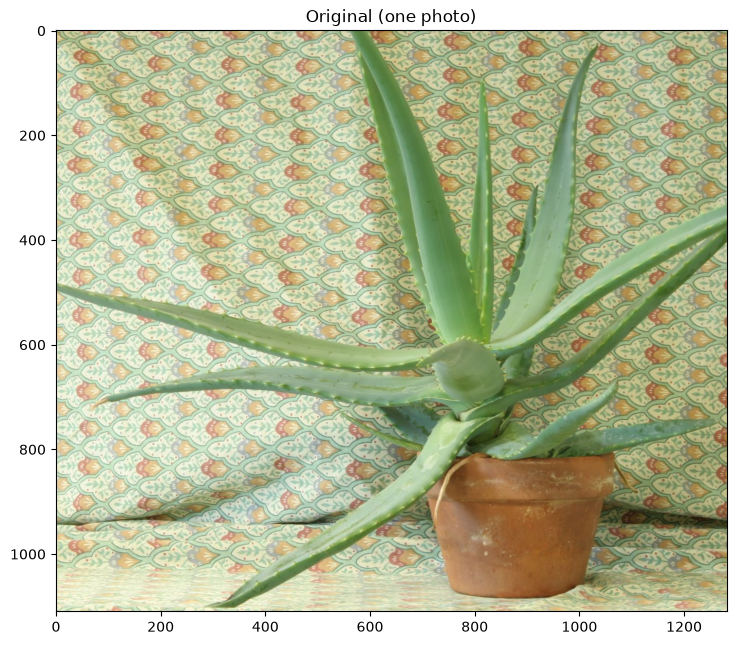

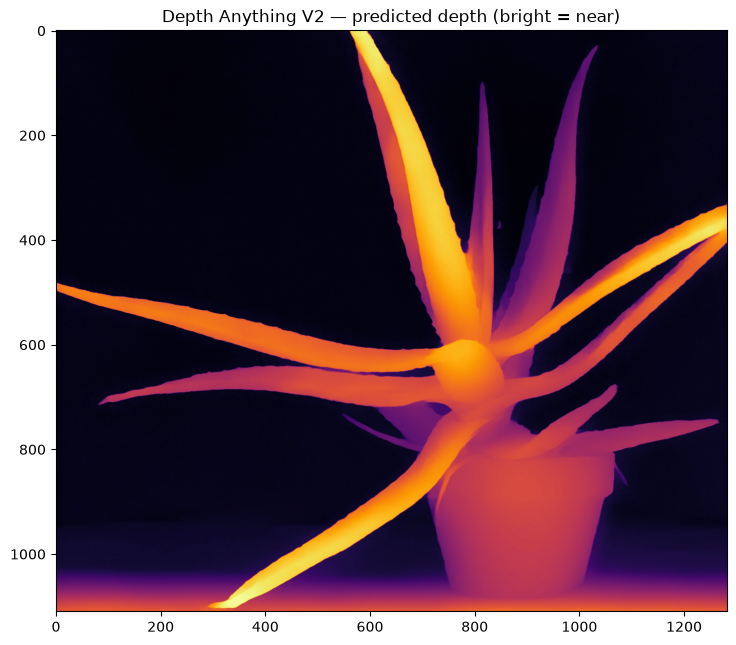

In [2]:
import onnxruntime as ort

aloe_l = cv2.imread('assets/images/aloeL.jpg')
aloe_gt = cv2.imread('assets/images/aloeGT.png', cv2.IMREAD_GRAYSCALE)
h, w = aloe_l.shape[:2]

rgb = cv2.cvtColor(aloe_l, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
target_h, target_w = round(h / 14) * 14, round(w / 14) * 14
resized = cv2.resize(rgb, (target_w, target_h))

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
chw = ((resized - mean) / std).transpose(2, 0, 1)[None].astype(np.float32)

depth_model = ort.InferenceSession('assets/models/depth_anything_v2_small.onnx')
pred = depth_model.run(None, {'pixel_values': chw})[0][0]  # higher value = nearer
pred_full = cv2.resize(pred, (w, h))  # back to aloeL's native resolution

depth_vis = cv2.normalize(pred_full, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
imshow('Original (one photo)', aloe_l)
imshow('Depth Anything V2 — predicted depth (bright = near)', cv2.applyColorMap(depth_vis, cv2.COLORMAP_INFERNO))

## **Checking against real ground truth — same test notebook 32 ran**

Same split, same reasoning as notebook 32: the *background* (flat, distant wall) can't be graded because `aloeGT.png` itself labels that whole region a flat 0, not a measured depth. The *foreground* leaves — real, independently measured distances — are the honest test.

In [3]:
def masked_corr(pred, gt, mask):
    p, g = pred[mask], gt[mask].astype(np.float32)
    if g.std() == 0:
        return None  # undefined — same flat-wall reason as notebook 32
    return np.corrcoef(p, g)[0, 1]

background = aloe_gt < 40
foreground = aloe_gt >= 40

bg_corr = masked_corr(pred_full, aloe_gt, background)
fg_corr = masked_corr(pred_full, aloe_gt, foreground)
bg_str = f'{bg_corr:.2f}' if bg_corr is not None else 'undefined (flat wall, see notebook 32)'
print(f'Depth Anything V2 (single photo): background corr={bg_str}, foreground (leaves) corr={fg_corr:.2f}')
print('StereoSGBM (notebook 32, two photos + calibration):        background corr=undefined,           foreground (leaves) corr=0.93')

Depth Anything V2 (single photo): background corr=undefined (flat wall, see notebook 32), foreground (leaves) corr=0.93
StereoSGBM (notebook 32, two photos + calibration):        background corr=undefined,           foreground (leaves) corr=0.93


## **The surprising part**

Depth Anything's foreground correlation against real measured ground truth lands at **~0.93** — statistically tied with `StereoSGBM`'s **0.93** from notebook 32, on the same leaves, graded against the same ground truth. A model that never saw a second camera, never computed a single pixel correspondence, and has no idea what a baseline is, matches a purpose-built geometric method almost exactly on relative depth ordering.

That's not stereo being unnecessary — it's the opposite kind of tool for a reason: stereo's output is real metric depth with a traceable derivation from physics, usable the moment you know $f$ and $B$ (notebook 32's closing exercise converts it to meters directly). Depth Anything's output is only ever *relative* — this photo's leaves are nearer than this photo's wall — with no way to say by how many centimeters without an external scale reference. Reach for stereo (or an actual depth sensor) when you need real distances; reach for a monocular model like this one when you only have one camera, or one archival photo, and relative depth is enough.

### A few ideas to play with

- Run Depth Anything on `assets/images/aloeR.jpg` too, and check how much the predicted depth map actually changes between the two views — a real single-image method should barely notice the ~6cm camera shift that gives stereo its whole signal.
- Try a photo with no calibrated stereo pair at all (`assets/images/tobago.jpg` or `castara.jpeg`) — this is the situation Depth Anything is actually for, where notebook 32's approach has no second view to work with.
- Swap in the larger `depth-anything-v2-base` or `-large` checkpoint (CC-BY-NC-4.0 — non-commercial only, so don't bundle it here) and see whether the foreground correlation genuinely improves over Small's ~0.93, or is already close to this scene's ceiling.